### Phân tích và Trực quan hóa Dữ liệu Bệnh Tim với Matplotlib

Giới thiệu
Notebook này thực hiện phân tích khám phá (Exploratory Data Analysis - EDA) trên bộ dữ liệu heart_cleveland_upload.csv. Mục tiêu là sử dụng thư viện Matplotlib để tạo ra các biểu đồ, giúp hiểu rõ hơn về đặc điểm của dữ liệu và mối quan hệ giữa các thuộc tính khác nhau liên quan đến bệnh tim.
Các thư viện sử dụng:
pandas để tải và xử lý dữ liệu.
matplotlib.pyplot để vẽ biểu đồ.
<hr></hr>
** 1. Tải và kiểm tra dữ liệu**

Bước đầu tiên là tải dữ liệu từ file CSV vào một DataFrame của pandas và kiểm tra một vài dòng đầu tiên để đảm bảo dữ liệu được đọc chính xác.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Tải dữ liệu
file_path = 'dataset/heart_cleveland_upload.csv'
df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
print("Dữ liệu 5 dòng đầu tiên:")
print(df.head())

# Hiển thị thông tin tổng quan về dữ liệu
print("\nThông tin tổng quan (dtypes, non-null counts):")
df.info()

Dữ liệu 5 dòng đầu tiên:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Thông tin tổng quan (dtypes, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-n

#### 2. Biểu đồ tròn: Phân bổ Giới tính

- Biểu đồ này cho thấy tỷ lệ phần trăm giữa nam và nữ trong bộ dữ liệu. Điều này giúp chúng ta hiểu về cơ cấu giới tính của các bệnh nhân được khảo sát.
- Nhận xét: Dữ liệu cho thấy số lượng bệnh nhân nam chiếm tỷ lệ lớn hơn đáng kể so với bệnh nhân nữ.


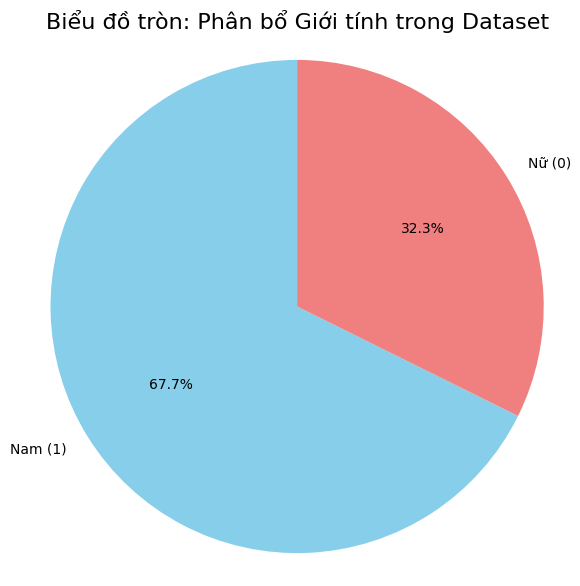

In [4]:
# Chuẩn bị dữ liệu
sex_counts = df['sex'].value_counts()
labels = ['Nam (1)', 'Nữ (0)']
sizes = sex_counts.values

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
ax.axis('equal')  # Đảm bảo biểu đồ tròn
ax.set_title('Biểu đồ tròn: Phân bổ Giới tính trong Dataset', fontsize=16)
plt.show()

<hr></hr>

#### 3. Biểu đồ cột: Tình trạng Bệnh tim (Target)
- Biểu đồ này trực quan hóa sự phân bổ của biến mục tiêu (condition), cho biết số lượng người có bệnh và không có bệnh tim. Đây là biểu đồ quan trọng nhất để hiểu sự cân bằng của dữ liệu.
- Nhận xét: Số lượng người không mắc bệnh tim (condition=0) nhiều hơn một chút so với số người mắc bệnh (condition=1). Dữ liệu tương đối cân bằng.

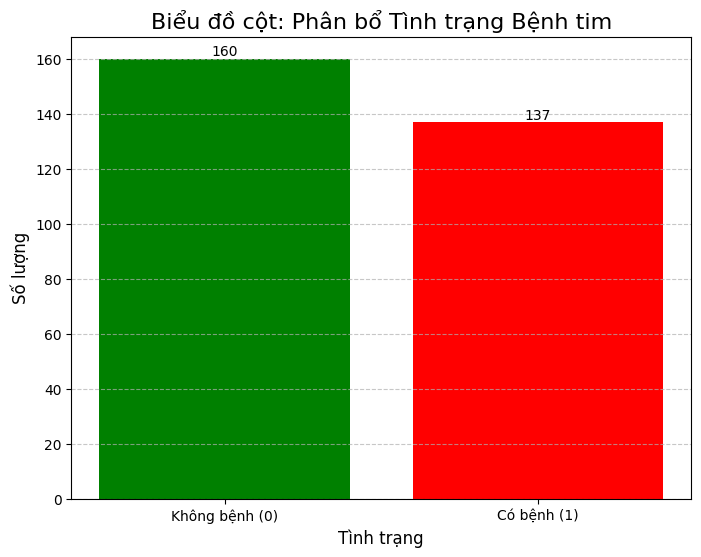

In [5]:
# Chuẩn bị dữ liệu
condition_counts = df['condition'].value_counts()
labels = ['Không bệnh (0)', 'Có bệnh (1)']
values = condition_counts.values

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=['green', 'red'])
plt.title('Biểu đồ cột: Phân bổ Tình trạng Bệnh tim', fontsize=16)
plt.xlabel('Tình trạng', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm nhãn số lượng trên mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

plt.show()

#### 4. Histogram: Phân phối Tuổi
Histogram này cho thấy tần suất xuất hiện của các nhóm tuổi khác nhau trong bộ dữ liệu. Nó giúp xác định độ tuổi phổ biến của các bệnh nhân.
Nhận xét: Phân phối tuổi của bệnh nhân tập trung chủ yếu trong khoảng từ 50 đến 65 tuổi.

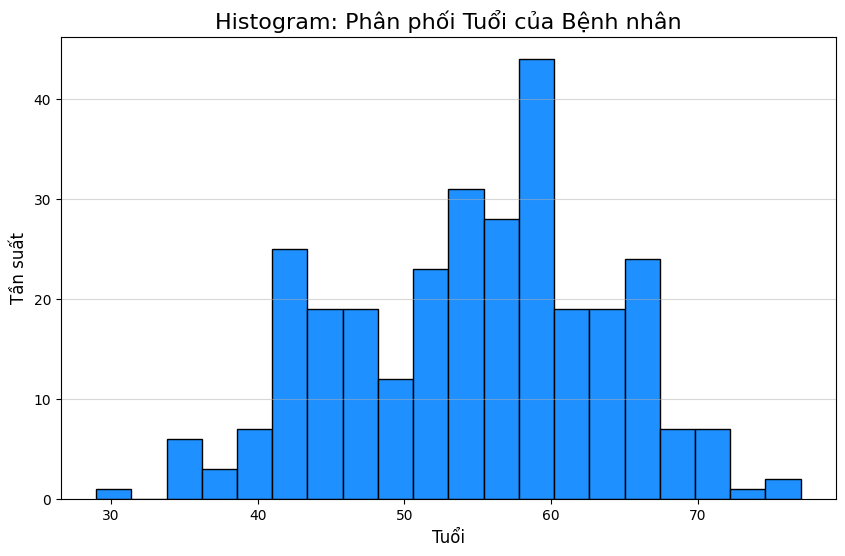

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, color='dodgerblue', edgecolor='black')
plt.title('Histogram: Phân phối Tuổi của Bệnh nhân', fontsize=16)
plt.xlabel('Tuổi', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

#### 5. Biểu đồ phân tán (Scatter Plot): Tuổi vs. Nhịp tim tối đa (thalach)

Biểu đồ này khám phá mối quan hệ giữa tuổi (age) và nhịp tim tối đa đạt được (thalach). Mỗi điểm đại diện cho một bệnh nhân.
Nhận xét: Có một xu hướng giảm rõ rệt: người càng lớn tuổi thì nhịp tim tối đa đạt được càng có xu hướng thấp hơn.

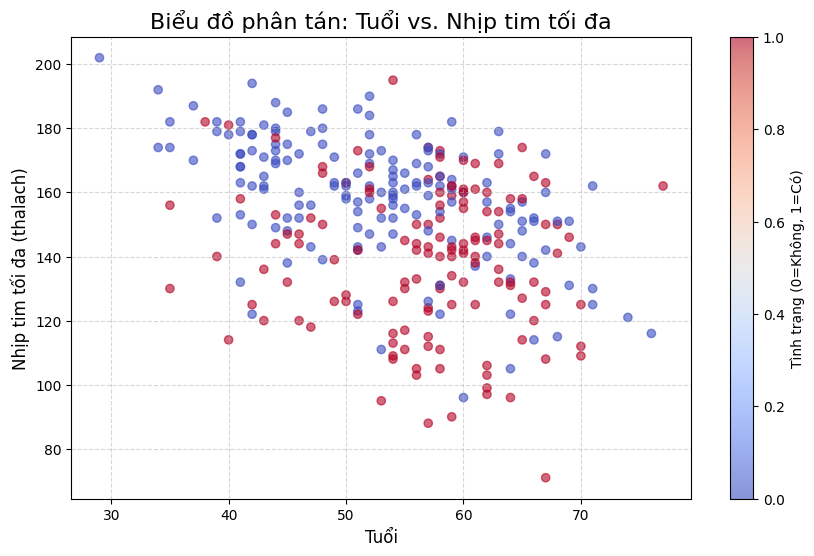

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['age'], df['thalach'], alpha=0.6, c=df['condition'], cmap='coolwarm')
plt.title('Biểu đồ phân tán: Tuổi vs. Nhịp tim tối đa', fontsize=16)
plt.xlabel('Tuổi', fontsize=12)
plt.ylabel('Nhịp tim tối đa (thalach)', fontsize=12)
plt.colorbar(label='Tình trạng (0=Không, 1=Có)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 6. Biểu đồ hộp (Box Plot): Cholesterol theo Tình trạng Bệnh

Biểu đồ hộp so sánh phân phối của mức cholesterol (chol) giữa hai nhóm: người có bệnh tim và người không có bệnh tim.
Nhận xét: Mức cholesterol của cả hai nhóm có vẻ khá tương đồng. Phân vị trung bình (đường giữa hộp) của nhóm có bệnh tim có vẻ cao hơn một chút, nhưng sự khác biệt không quá lớn. Cả hai nhóm đều có các giá trị ngoại lai (outliers).

C:\Users\dell\AppData\Local\Temp\ipykernel_11352\4198924525.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([chol_no_disease, chol_disease], labels=['Không bệnh', 'Có bệnh'])


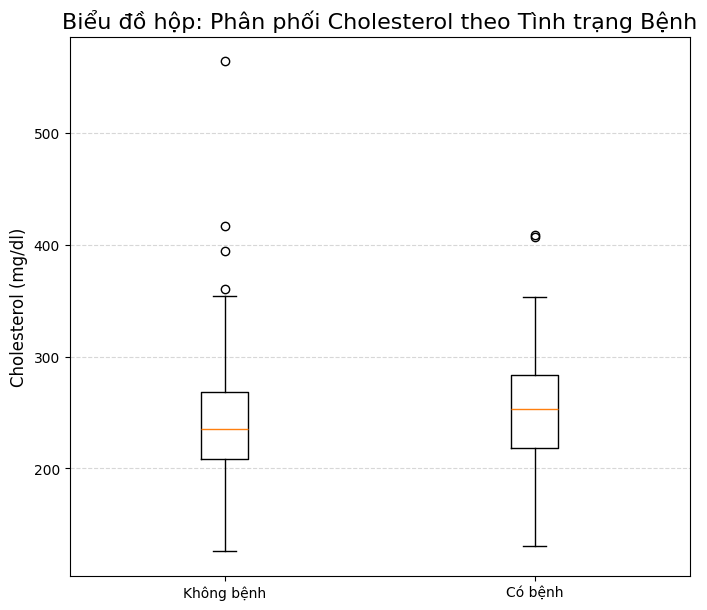

In [8]:
# Tách dữ liệu
chol_no_disease = df[df['condition'] == 0]['chol']
chol_disease = df[df['condition'] == 1]['chol']

# Vẽ biểu đồ
plt.figure(figsize=(8, 7))
plt.boxplot([chol_no_disease, chol_disease], labels=['Không bệnh', 'Có bệnh'])
plt.title('Biểu đồ hộp: Phân phối Cholesterol theo Tình trạng Bệnh', fontsize=16)
plt.ylabel('Cholesterol (mg/dl)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### 7. Biểu đồ cột nhóm: Loại đau ngực (cp) và Tình trạng Bệnh
Biểu đồ này so sánh số lượng bệnh nhân theo từng loại đau ngực (cp), được phân chia theo việc họ có mắc bệnh tim hay không.
Nhận xét: Bệnh nhân không có triệu chứng đau ngực (Loại 0) chiếm tỷ lệ mắc bệnh tim cao nhất. Ngược lại, những người có các loại đau ngực khác (1, 2) lại có tỷ lệ không mắc bệnh cao hơn.

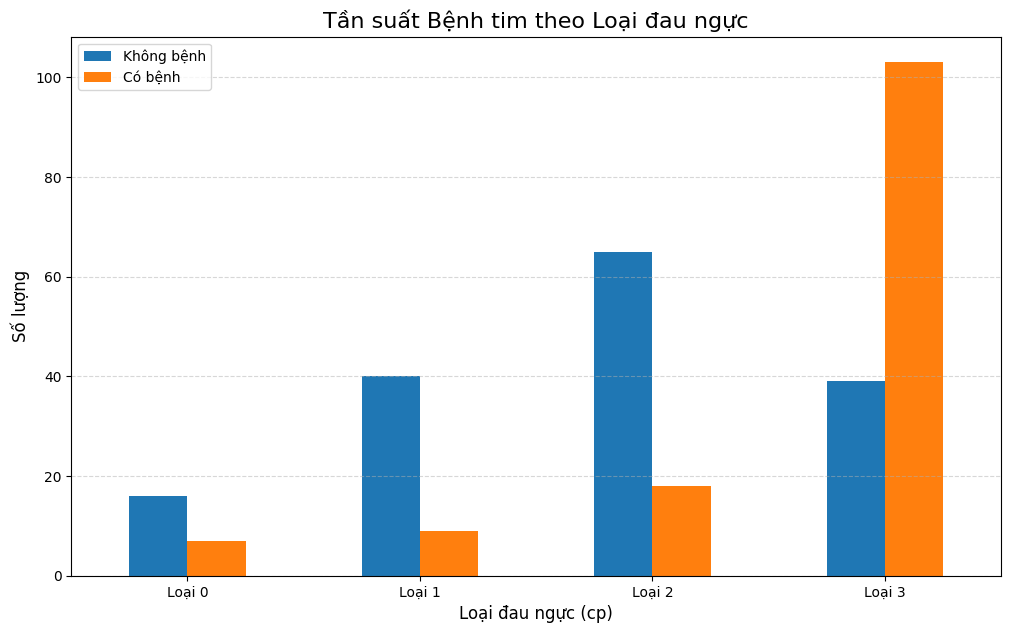

In [9]:
# Tạo bảng chéo
pd.crosstab(df.cp, df.condition).plot(kind="bar", figsize=(12, 7), color=['#1f77b4', '#ff7f0e'])
plt.title('Tần suất Bệnh tim theo Loại đau ngực', fontsize=16)
plt.xlabel('Loại đau ngực (cp)', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Loại 0', 'Loại 1', 'Loại 2', 'Loại 3'], rotation=0)
plt.legend(['Không bệnh', 'Có bệnh'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### 8. Histogram: Phân phối Huyết áp lúc nghỉ (trestbps)
Biểu đồ này cho thấy sự phân bố của huyết áp tâm thu lúc nghỉ của các bệnh nhân trong bộ dữ liệu.
Nhận xét: Hầu hết bệnh nhân có huyết áp lúc nghỉ trong khoảng 120-140 mmHg. Phân phối có vẻ hơi lệch phải.

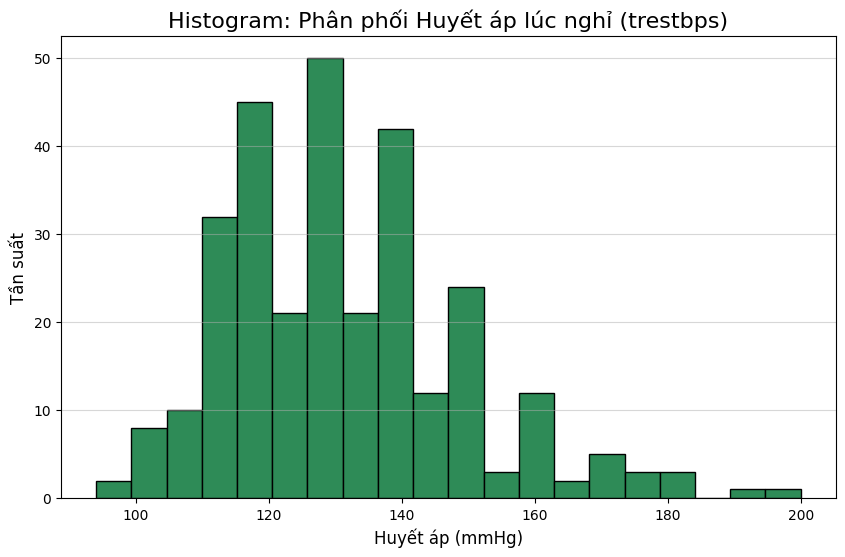

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df['trestbps'], bins=20, color='seagreen', edgecolor='black')
plt.title('Histogram: Phân phối Huyết áp lúc nghỉ (trestbps)', fontsize=16)
plt.xlabel('Huyết áp (mmHg)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

#### 9. Biểu đồ Violin: Tuổi theo Tình trạng Bệnh
Biểu đồ Violin kết hợp ưu điểm của biểu đồ hộp và biểu đồ mật độ. Nó cho thấy phân phối đầy đủ của dữ liệu tuổi cho cả hai nhóm bệnh nhân.
Nhận xét: Phân phối tuổi của nhóm không mắc bệnh có vẻ trẻ hơn một chút và tập trung hơn so với nhóm mắc bệnh. Nhóm mắc bệnh có phân phối tuổi rộng hơn và có xu hướng lớn tuổi hơn.

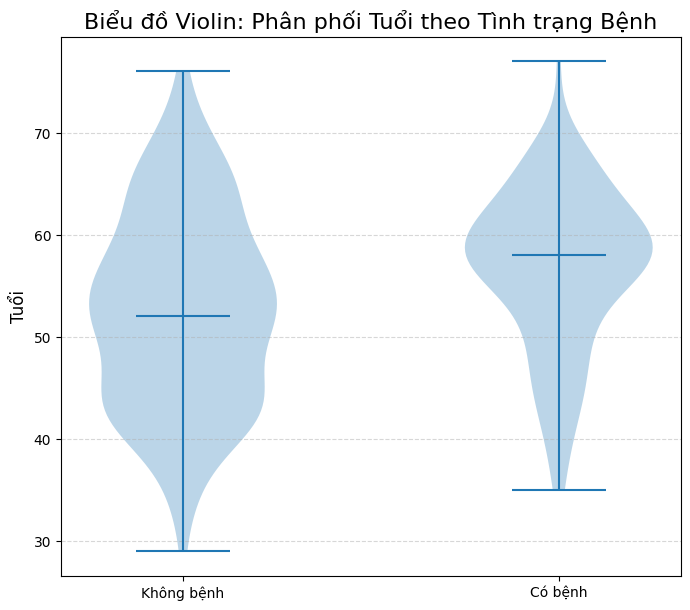

In [11]:
# Tách dữ liệu
age_no_disease = df[df['condition'] == 0]['age']
age_disease = df[df['condition'] == 1]['age']

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(8, 7))
ax.violinplot([age_no_disease, age_disease], showmedians=True)
ax.set_title('Biểu đồ Violin: Phân phối Tuổi theo Tình trạng Bệnh', fontsize=16)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Không bệnh', 'Có bệnh'])
ax.set_ylabel('Tuổi', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### 10. Biểu đồ phân tán: Cholesterol (chol) vs. Huyết áp (trestbps)
Biểu đồ này khám phá mối quan hệ giữa hai chỉ số sức khỏe quan trọng: cholesterol và huyết áp. Màu sắc của các điểm cho biết tình trạng bệnh tim.
Nhận xét: Không có một mối quan hệ tuyến tính rõ ràng giữa cholesterol và huyết áp. Các bệnh nhân có và không có bệnh tim phân bố rải rác trên toàn bộ biểu đồ, cho thấy việc chỉ dựa vào hai yếu tố này là không đủ để chẩn đoán.

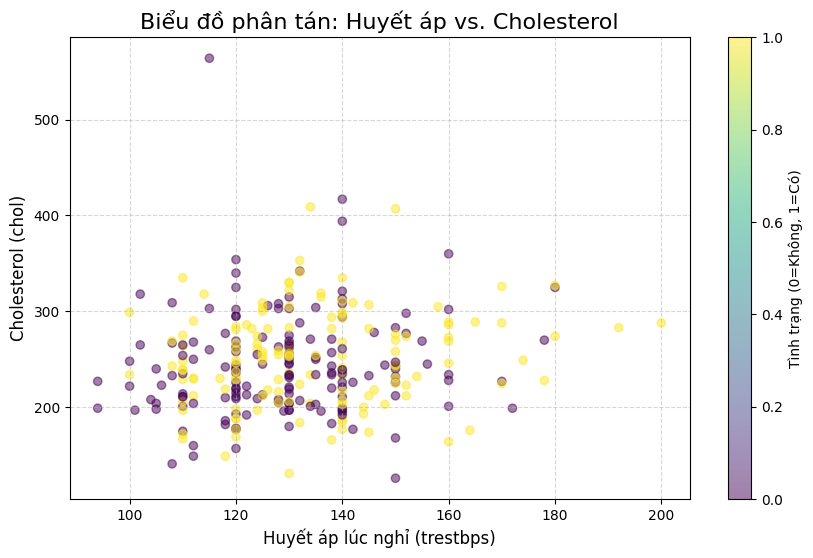

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['trestbps'], df['chol'], alpha=0.5, c=df['condition'], cmap='viridis')
plt.title('Biểu đồ phân tán: Huyết áp vs. Cholesterol', fontsize=16)
plt.xlabel('Huyết áp lúc nghỉ (trestbps)', fontsize=12)
plt.ylabel('Cholesterol (chol)', fontsize=12)
plt.colorbar(label='Tình trạng (0=Không, 1=Có)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 11. Ma trận tương quan (Heatmap)
Heatmap này trực quan hóa ma trận tương quan giữa tất cả các thuộc tính số trong bộ dữ liệu. Màu sắc biểu thị mức độ tương quan: màu nóng (đỏ) cho tương quan dương, màu lạnh (xanh) cho tương quan âm.
Nhận xét:
cp (loại đau ngực) và thalach (nhịp tim tối đa) có tương quan dương với condition (tình trạng bệnh).
exang (đau thắt ngực do gắng sức), oldpeak, và ca có tương quan âm mạnh với condition.
age và thalach có tương quan âm đáng chú ý như đã thấy trong biểu đồ phân tán.

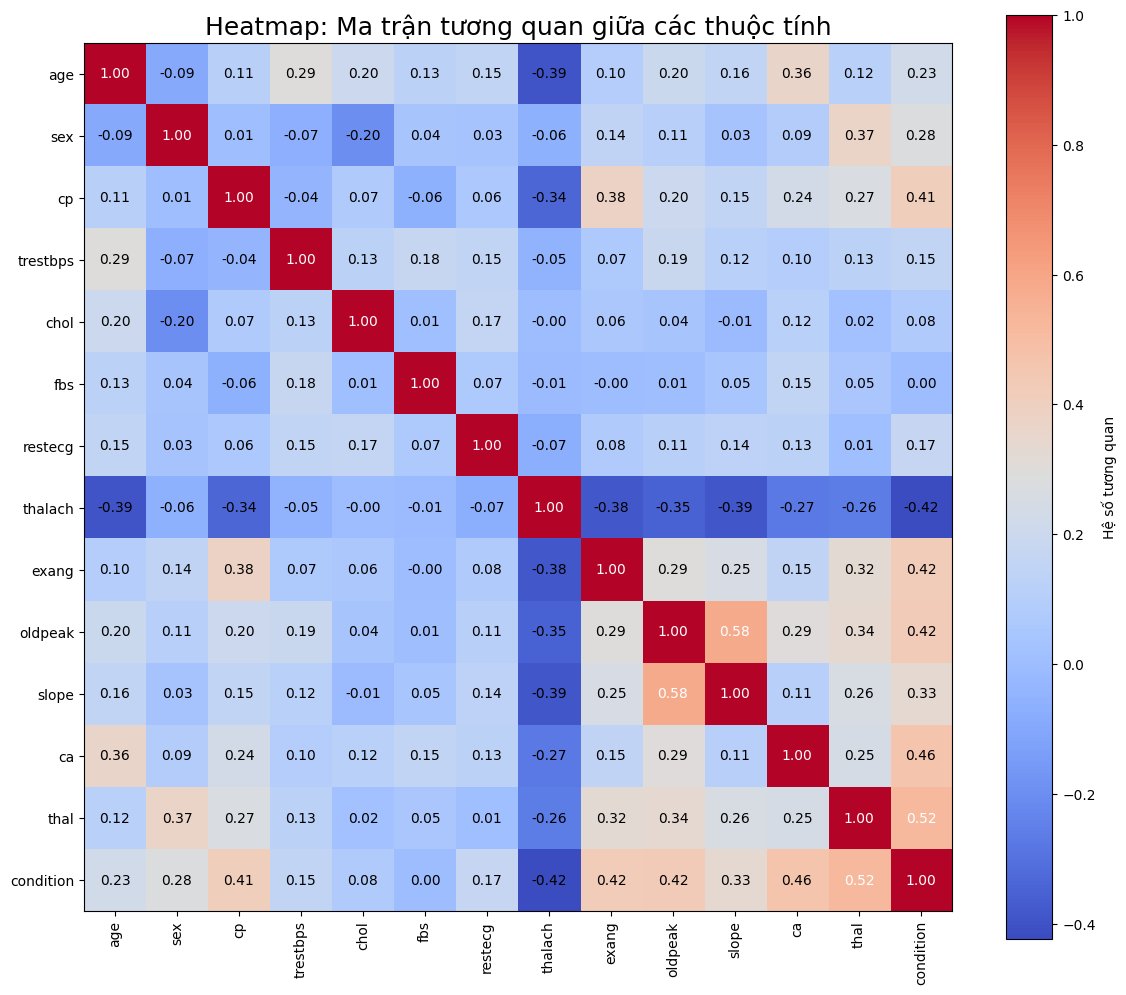

In [13]:
# Tính toán ma trận tương quan
corr_matrix = df.corr()

# Vẽ heatmap
plt.figure(figsize=(14, 12))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Hệ số tương quan')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Heatmap: Ma trận tương quan giữa các thuộc tính', fontsize=18)

# Thêm giá trị vào các ô
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

plt.show()